In [1]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 6.6 MB/s eta 0:00:00


In [2]:
import neurokit2 as nk

In [3]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git

  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-y1cj90yt
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-y1cj90yt
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.1 MB/s eta 0:00:00
  Created wheel for signaldraw-isb: filename=signaldraw_isb-0.1.0-py3-none-any.whl size=7729 sha256=3ef41898e99f96dc9c2d220a0bbd670ef7f235f45497347820676ba944915ca1
  Stored in directory: /tmp/pip-ephem-wheel-cache-2h1kgfuo/wheels/a1/6a/b2/5fbb64642172e5c20aeab3e137b6f969bfed7f9c1dafde72b1
Successfully built signaldraw-isb


In [4]:
from signaldraw_isb import SignalDraw

In [5]:
!pip install scipy

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter

In [7]:
# EJERCICIO 1

frecuencia_muestreo = 1000
duracion = 10
tiempo = np.arange(0, duracion, 1/frecuencia_muestreo)

senal_5hz = 0.5 * np.sin(2 * np.pi * 5 * tiempo)
senal_20hz = 1.0 * np.sin(2 * np.pi * 20 * tiempo)
senal_80hz = 0.7 * np.sin(2 * np.pi * 80 * tiempo)

senal_ecg_simulada = senal_5hz + senal_20hz + senal_80hz

orden_filtro = 151
frecuencia_baja = 15
frecuencia_alta = 30

coeficientes_fir = firwin(
    orden_filtro,
    [frecuencia_baja, frecuencia_alta],
    pass_zero=False,
    fs=frecuencia_muestreo
)


senal_filtrada = lfilter(coeficientes_fir, 1.0, senal_ecg_simulada)

retardo = (orden_filtro - 1) // 2
senal_filtrada_ajustada = np.roll(senal_filtrada, -retardo)

#Calcular FFT
def calcular_fft(senal, fs):
    n = len(senal)
    frecuencias = np.fft.rfftfreq(n, d=1/fs)
    magnitud = (2/n) * np.abs(np.fft.rfft(senal))
    return frecuencias, magnitud

#FFT antes y después
freq_original, fft_original = calcular_fft(senal_ecg_simulada, frecuencia_muestreo)
freq_filtrada, fft_filtrada = calcular_fft(senal_filtrada_ajustada, frecuencia_muestreo)

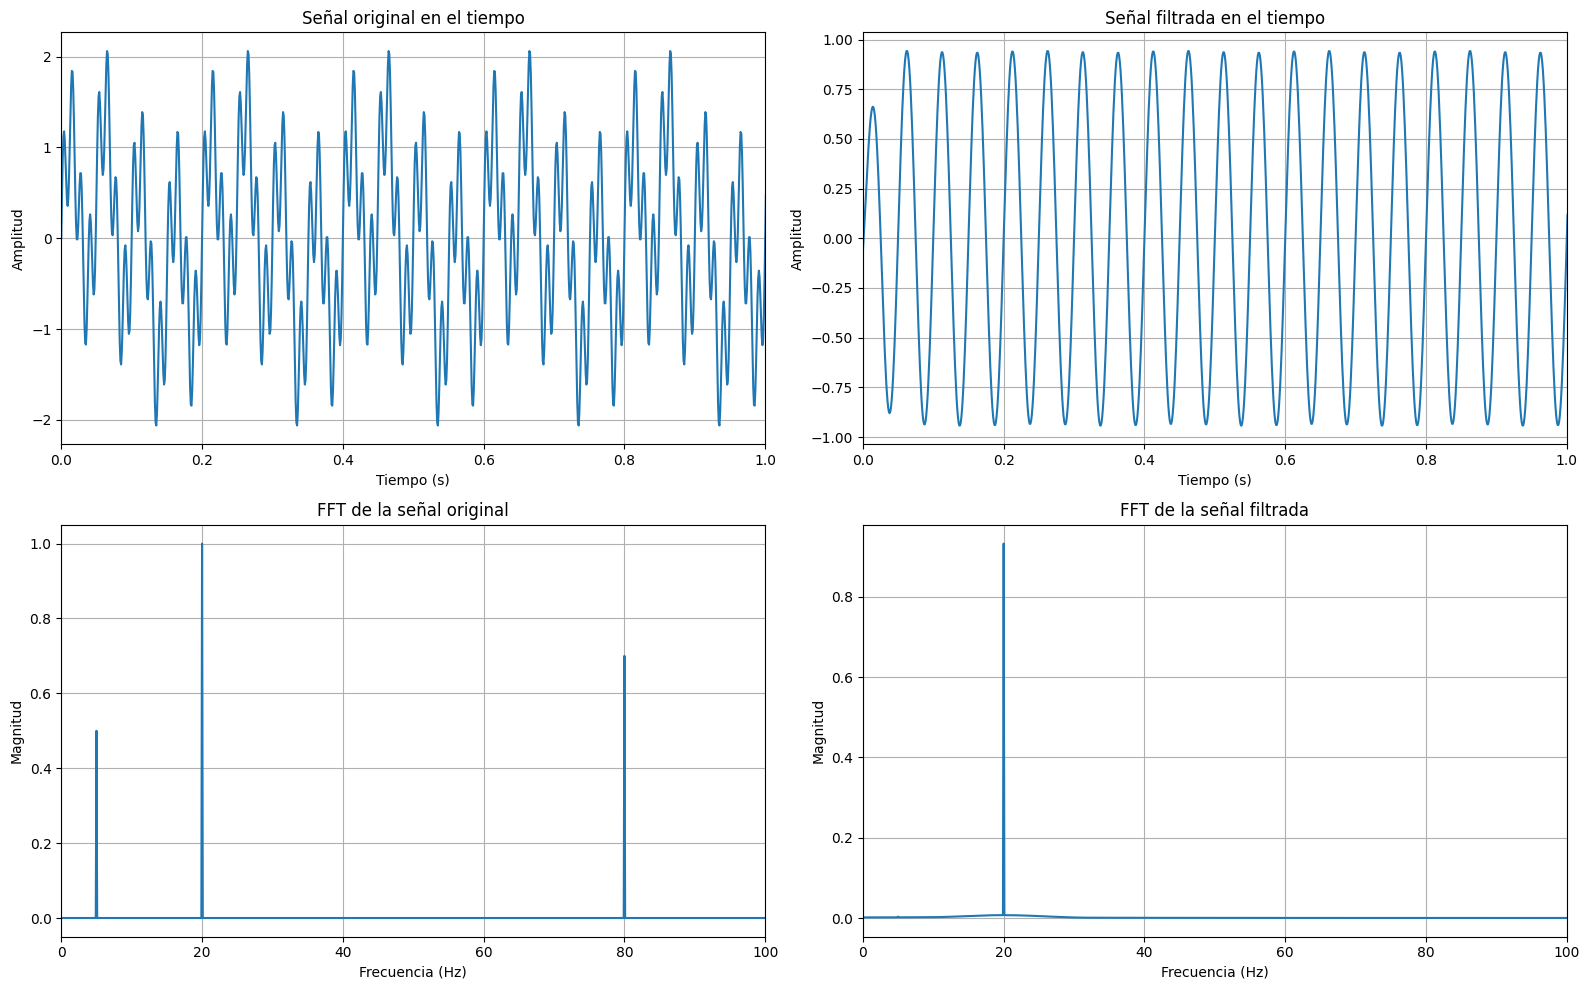

La señal original contiene tres componentes principales: 5 Hz, 20 Hz y 80 Hz.
Luego de aplicar el filtro pasa banda de 15 Hz a 30 Hz, la componente de 20 Hz se conserva.
Las componentes de 5 Hz y 80 Hz son atenuadas porque están fuera de la banda permitida.


In [8]:
plt.figure(figsize=(16, 10))

#Señal antes del filtro
plt.subplot(2, 2, 1)
plt.plot(tiempo, senal_ecg_simulada)
plt.title("Señal original en el tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 1)
plt.grid(True)

#Señal después del filtro
plt.subplot(2, 2, 2)
plt.plot(tiempo, senal_filtrada_ajustada)
plt.title("Señal filtrada en el tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 1)
plt.grid(True)

#FFT antes
plt.subplot(2, 2, 3)
plt.plot(freq_original, fft_original)
plt.title("FFT de la señal original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 100)
plt.grid(True)

#FFT después
plt.subplot(2, 2, 4)
plt.plot(freq_filtrada, fft_filtrada)
plt.title("FFT de la señal filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 100)
plt.grid(True)

plt.tight_layout()
plt.show()

print("La señal original contiene tres componentes principales: 5 Hz, 20 Hz y 80 Hz.")
print("Luego de aplicar el filtro pasa banda de 15 Hz a 30 Hz, la componente de 20 Hz se conserva.")
print("Las componentes de 5 Hz y 80 Hz son atenuadas porque están fuera de la banda permitida.")

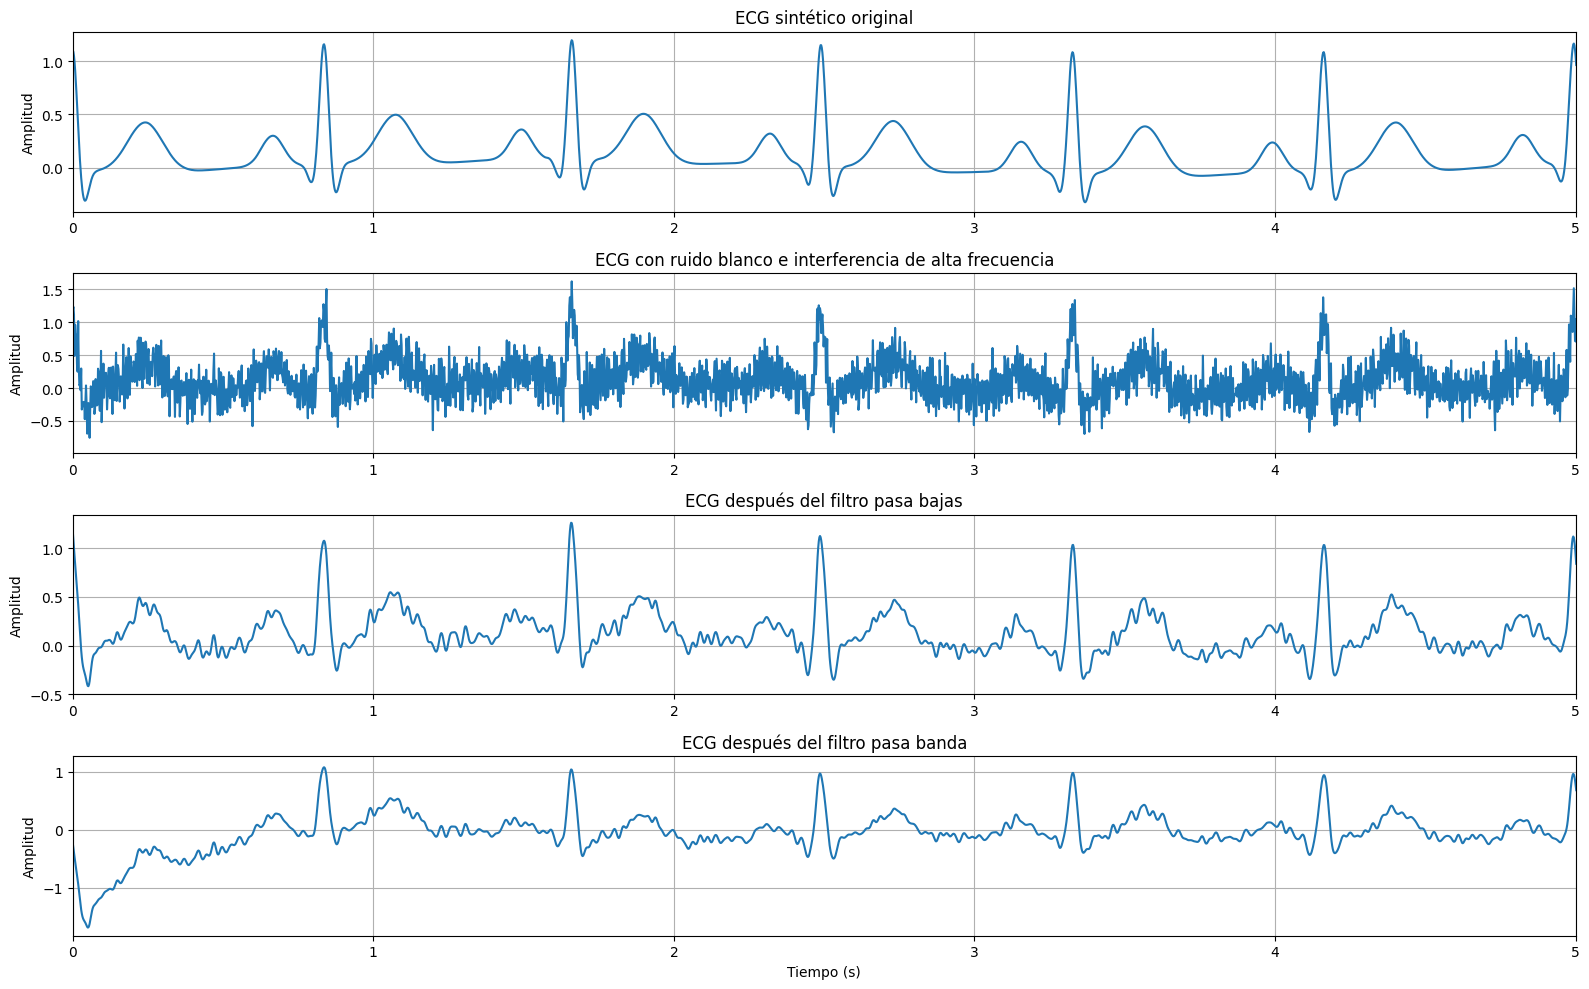

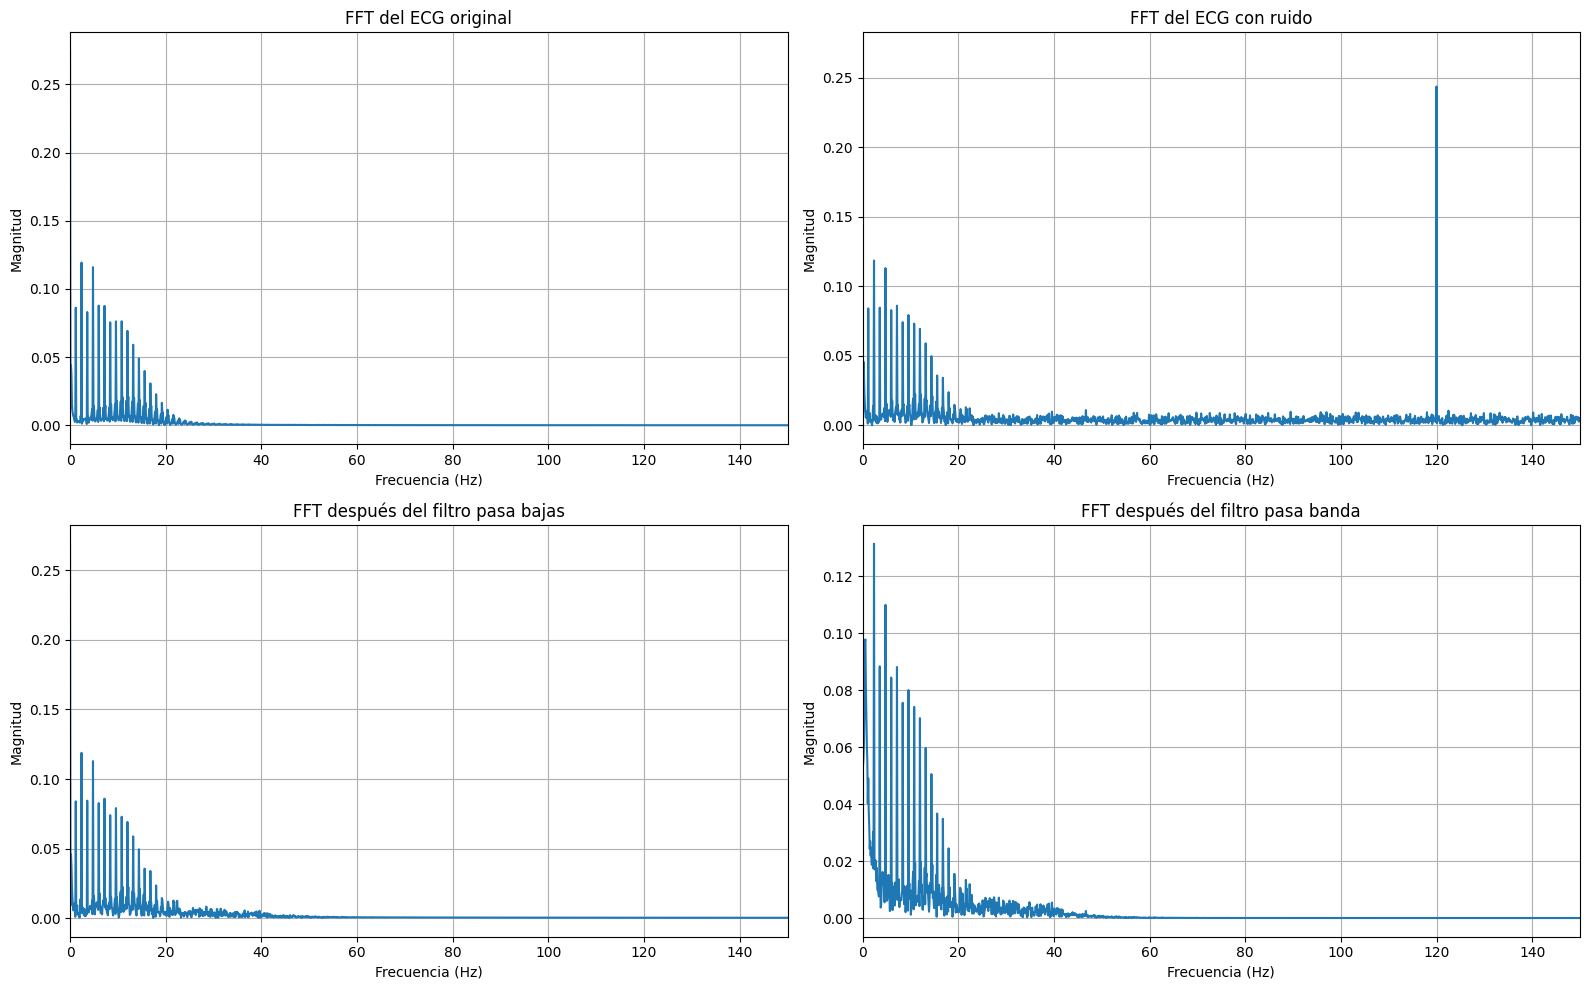

In [9]:
#EJERCICIO 2: ELIMINACIÓN DE RUIDO BLANCO
# Librerías adicionales para el Ejercicio 2
import neurokit2 as nk
from scipy.signal import butter, filtfilt

fs_ecg = 500
duracion_ecg = 10
tiempo_ecg = np.arange(0, duracion_ecg, 1/fs_ecg)

ecg_original = nk.ecg_simulate(
    duration=duracion_ecg,
    sampling_rate=fs_ecg,
    heart_rate=72,
    noise=0
)

#Ruido blanco
np.random.seed(12)
ruido_blanco = 0.15 * np.random.normal(0, 1, len(ecg_original))

#Interferencia de alta frecuencia
interferencia_hf = 0.25 * np.sin(2 * np.pi * 120 * tiempo_ecg)

#ECG contaminada
ecg_con_ruido = ecg_original + ruido_blanco + interferencia_hf

#FILTRO PASA BAJAS

orden_lowpass = 4
frecuencia_corte_low = 40

b_low, a_low = butter(
    orden_lowpass,
    frecuencia_corte_low,
    btype='low',
    fs=fs_ecg
)

ecg_filtrado_lowpass = filtfilt(b_low, a_low, ecg_con_ruido)

#FILTRO PASA BANDA

orden_bandpass = 4
frecuencia_inferior = 0.5
frecuencia_superior = 40

b_band, a_band = butter(
    orden_bandpass,
    [frecuencia_inferior, frecuencia_superior],
    btype='bandpass',
    fs=fs_ecg
)

ecg_filtrado_bandpass = filtfilt(b_band, a_band, ecg_con_ruido)

#calcular FFT
def obtener_fft(senal, fs):
    n = len(senal)
    frecuencias = np.fft.rfftfreq(n, d=1/fs)
    magnitud = (2/n) * np.abs(np.fft.rfft(senal))
    return frecuencias, magnitud

# FFT de las señales
freq_original, fft_original = obtener_fft(ecg_original, fs_ecg)
freq_ruido, fft_ruido = obtener_fft(ecg_con_ruido, fs_ecg)
freq_low, fft_low = obtener_fft(ecg_filtrado_lowpass, fs_ecg)
freq_band, fft_band = obtener_fft(ecg_filtrado_bandpass, fs_ecg)

# EN EL TIEMPO

plt.figure(figsize=(16, 10))

plt.subplot(4, 1, 1)
plt.plot(tiempo_ecg, ecg_original)
plt.title("ECG sintético original")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(tiempo_ecg, ecg_con_ruido)
plt.title("ECG con ruido blanco e interferencia de alta frecuencia")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(tiempo_ecg, ecg_filtrado_lowpass)
plt.title("ECG después del filtro pasa bajas")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(tiempo_ecg, ecg_filtrado_bandpass)
plt.title("ECG después del filtro pasa banda")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.tight_layout()
plt.show()

#FFT

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(freq_original, fft_original)
plt.title("FFT del ECG original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 150)
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(freq_ruido, fft_ruido)
plt.title("FFT del ECG con ruido")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 150)
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(freq_low, fft_low)
plt.title("FFT después del filtro pasa bajas")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 150)
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(freq_band, fft_band)
plt.title("FFT después del filtro pasa banda")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 150)
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
print("Se generó un ECG sintético y se contaminó con ruido blanco e interferencia de alta frecuencia de 120 Hz.")
print("El filtro pasa bajas reduce principalmente las componentes de alta frecuencia.")
print("El filtro pasa banda conserva la banda útil del ECG entre 0.5 Hz y 40 Hz.")
print("Después del filtrado, la señal ECG se observa más limpia y con menor interferencia.")

Se generó un ECG sintético y se contaminó con ruido blanco e interferencia de alta frecuencia de 120 Hz.
El filtro pasa bajas reduce principalmente las componentes de alta frecuencia.
El filtro pasa banda conserva la banda útil del ECG entre 0.5 Hz y 40 Hz.
Después del filtrado, la señal ECG se observa más limpia y con menor interferencia.


Posiciones de los 10 spikes:
[1966  612 2497 1288  387  663 1930 2038 1426 1440]


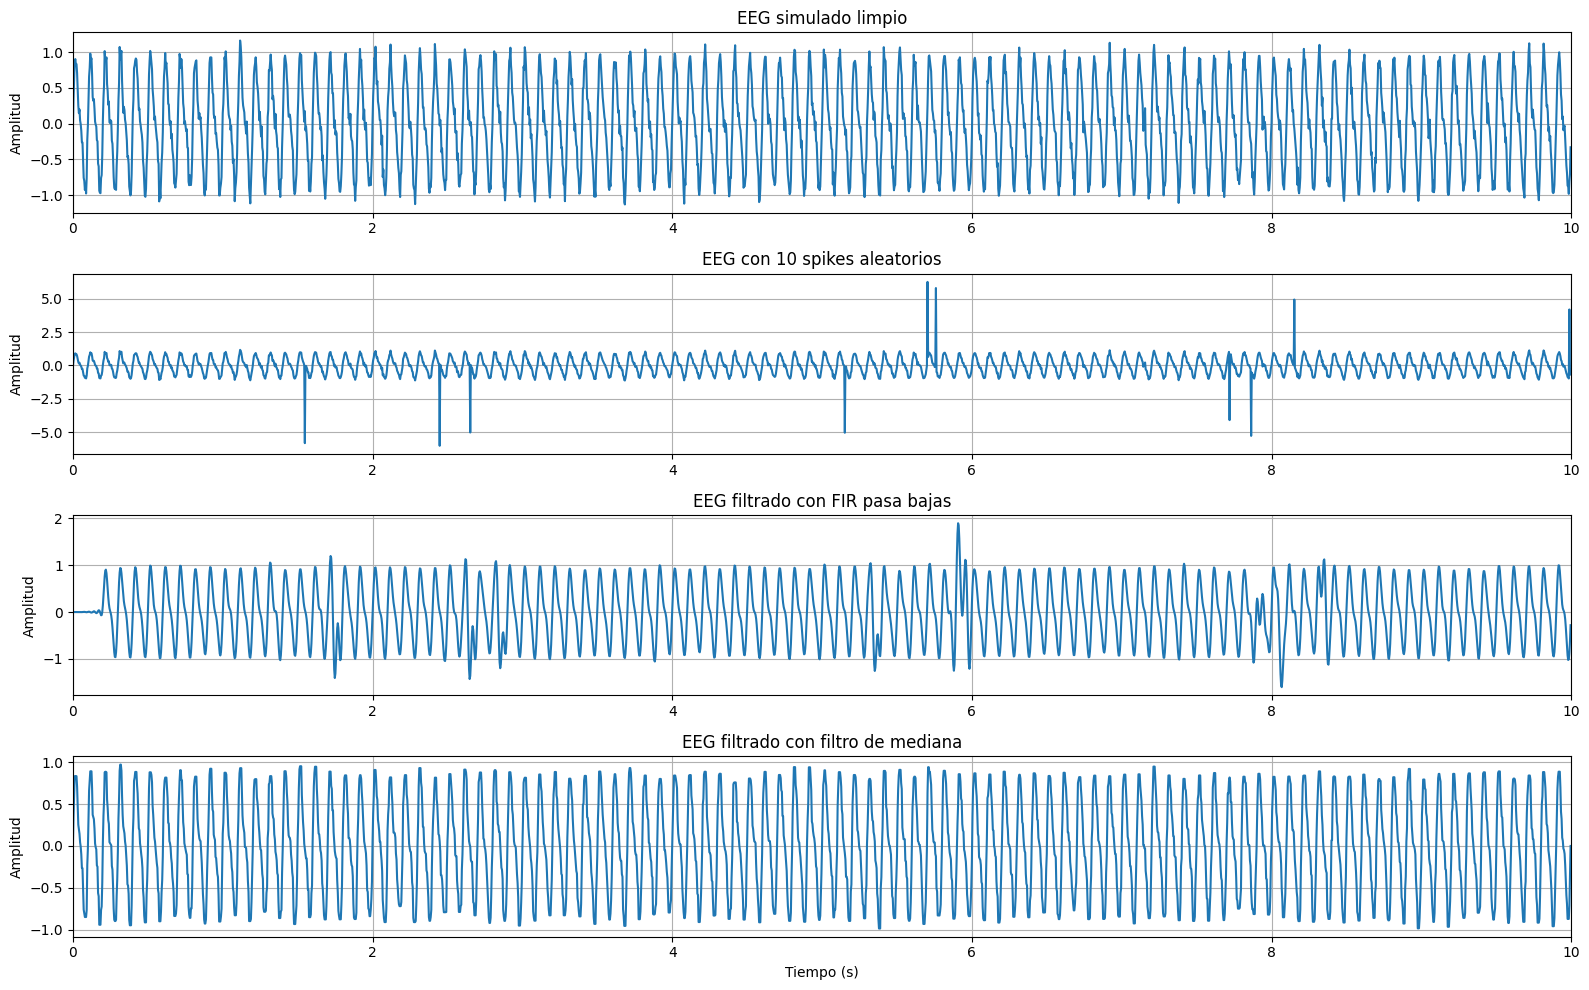

In [11]:
#EJERCICIO 3
from scipy.signal import medfilt

fs_eeg = 250
duracion_eeg = 10
tiempo_eeg = np.arange(0, duracion_eeg, 1/fs_eeg)

#combinación de ritmos cerebrales
ritmo_alpha = 0.8 * np.sin(2 * np.pi * 10 * tiempo_eeg)
ritmo_beta = 0.3 * np.sin(2 * np.pi * 20 * tiempo_eeg)
ruido_suave = 0.08 * np.random.normal(0, 1, len(tiempo_eeg))

eeg_limpia = ritmo_alpha + ritmo_beta + ruido_suave

#10 spikes aleatorios
np.random.seed(25)

eeg_con_spikes = eeg_limpia.copy()
posiciones_spikes = np.random.choice(len(eeg_con_spikes), size=10, replace=False)
amplitudes_spikes = np.random.choice([-6, -5, 5, 6], size=10)

for posicion, amplitud in zip(posiciones_spikes, amplitudes_spikes):
    eeg_con_spikes[posicion] = eeg_con_spikes[posicion] + amplitud

print("Posiciones de los 10 spikes:")
print(posiciones_spikes)

#FIR PASA BAJAS

orden_fir_eeg = 101
frecuencia_corte_eeg = 30   # Hz

filtro_fir_eeg = firwin(
    orden_fir_eeg,
    frecuencia_corte_eeg,
    pass_zero=True,
    fs=fs_eeg
)

eeg_fir_lowpass = lfilter(filtro_fir_eeg, 1.0, eeg_con_spikes)

#MEDIANA

eeg_mediana = medfilt(eeg_con_spikes, kernel_size=5)


plt.figure(figsize=(16, 10))

plt.subplot(4, 1, 1)
plt.plot(tiempo_eeg, eeg_limpia)
plt.title("EEG simulado limpio")
plt.ylabel("Amplitud")
plt.xlim(0, 10)
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(tiempo_eeg, eeg_con_spikes)
plt.title("EEG con 10 spikes aleatorios")
plt.ylabel("Amplitud")
plt.xlim(0, 10)
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(tiempo_eeg, eeg_fir_lowpass)
plt.title("EEG filtrado con FIR pasa bajas")
plt.ylabel("Amplitud")
plt.xlim(0, 10)
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(tiempo_eeg, eeg_mediana)
plt.title("EEG filtrado con filtro de mediana")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 10)
plt.grid(True)

plt.tight_layout()
plt.show()

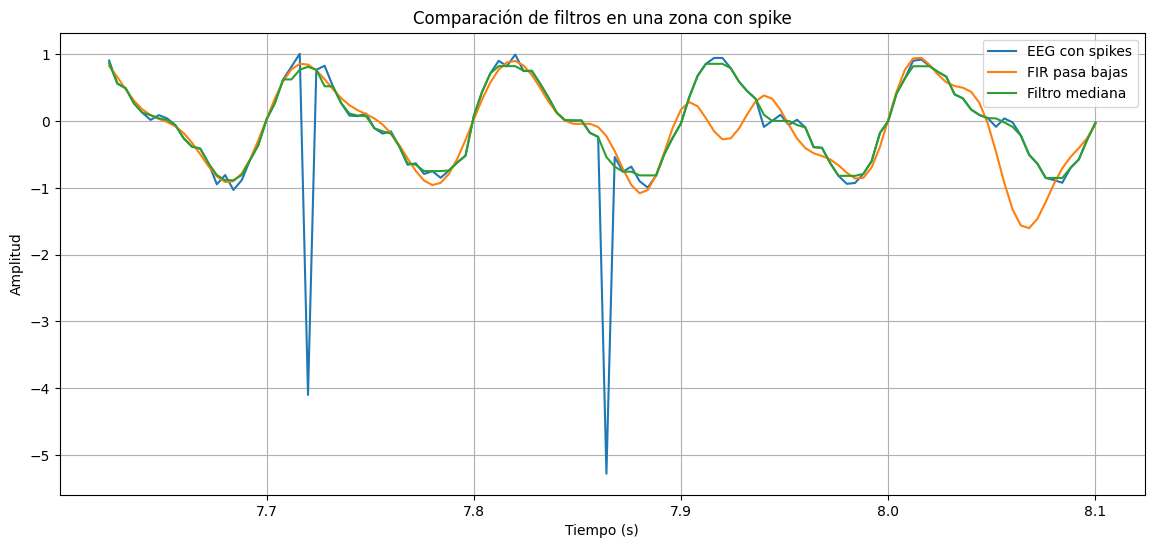

Se simuló una señal EEG compuesta por ritmos alfa y beta, y se agregaron 10 spikes aleatorios.
El filtro FIR pasa bajas reduce componentes de alta frecuencia, pero no elimina completamente los spikes impulsivos.
El filtro de mediana funciona mejor para este caso porque reemplaza valores abruptos aislados por valores más representativos de la vecindad.
Por ello, para ruido impulsivo producido por desconexiones instantáneas de electrodos, el filtro de mediana es más adecuado.


In [12]:
#ZOOM EN UNA ZONA CON SPIKE

spike_elegido = posiciones_spikes[0]
inicio_zoom = max(spike_elegido - 60, 0)
fin_zoom = min(spike_elegido + 60, len(eeg_con_spikes))

plt.figure(figsize=(14, 6))

plt.plot(tiempo_eeg[inicio_zoom:fin_zoom], eeg_con_spikes[inicio_zoom:fin_zoom], label="EEG con spikes")
plt.plot(tiempo_eeg[inicio_zoom:fin_zoom], eeg_fir_lowpass[inicio_zoom:fin_zoom], label="FIR pasa bajas")
plt.plot(tiempo_eeg[inicio_zoom:fin_zoom], eeg_mediana[inicio_zoom:fin_zoom], label="Filtro mediana")

plt.title("Comparación de filtros en una zona con spike")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.show()


print("Se simuló una señal EEG compuesta por ritmos alfa y beta, y se agregaron 10 spikes aleatorios.")
print("El filtro FIR pasa bajas reduce componentes de alta frecuencia, pero no elimina completamente los spikes impulsivos.")
print("El filtro de mediana funciona mejor para este caso porque reemplaza valores abruptos aislados por valores más representativos de la vecindad.")
print("Por ello, para ruido impulsivo producido por desconexiones instantáneas de electrodos, el filtro de mediana es más adecuado.")

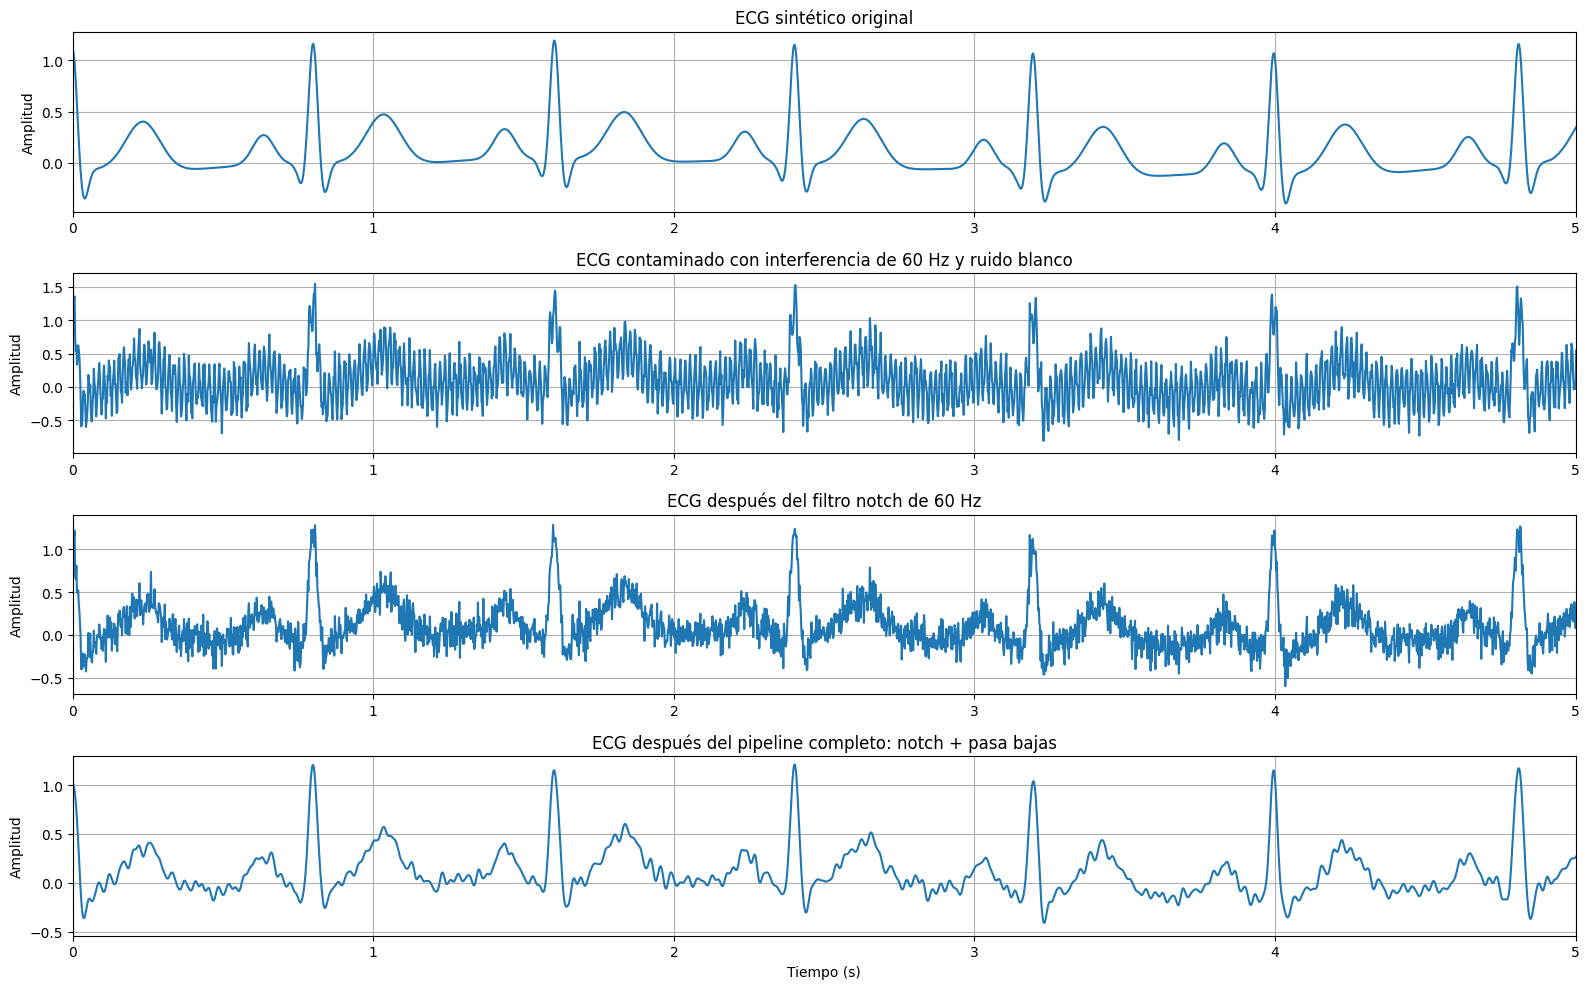

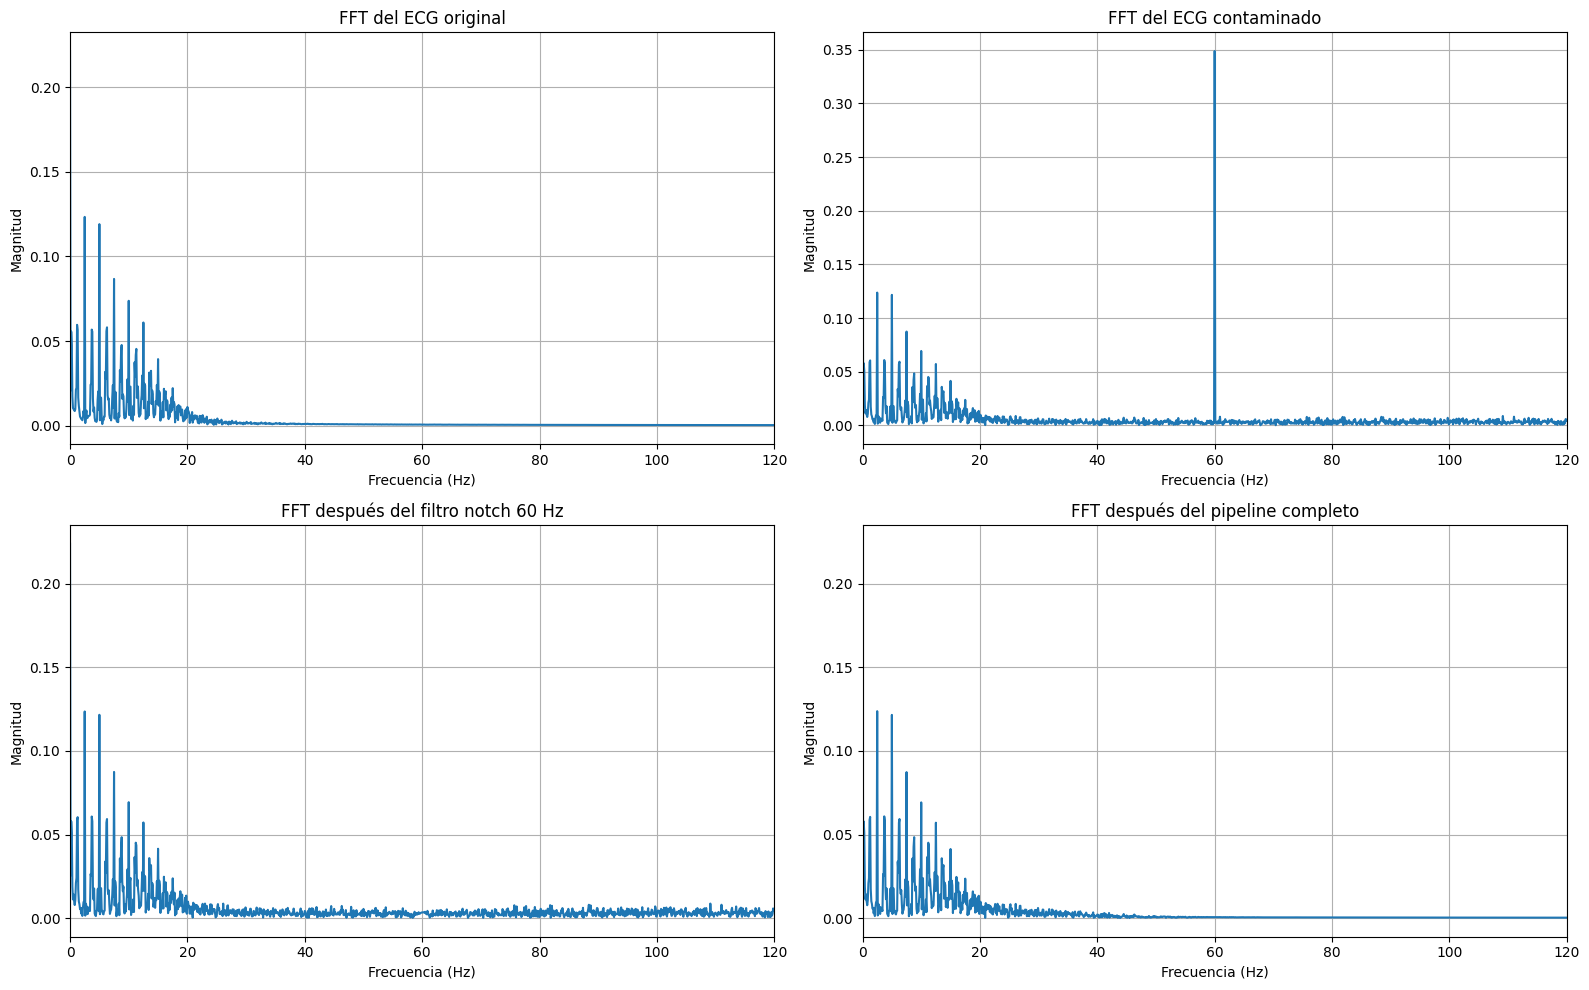

In [13]:
#EJERCICIO 4

from scipy.signal import iirnotch


fs_ecg4 = 500
duracion_ecg4 = 10
tiempo_ecg4 = np.arange(0, duracion_ecg4, 1/fs_ecg4)

#sintético
ecg_base = nk.ecg_simulate(
    duration=duracion_ecg4,
    sampling_rate=fs_ecg4,
    heart_rate=75,
    noise=0
)

#Interferencia eléctrica de 60 Hz
interferencia_60hz = 0.35 * np.sin(2 * np.pi * 60 * tiempo_ecg4)

# Ruido blanco
np.random.seed(40)
ruido_blanco_ecg = 0.12 * np.random.normal(0, 1, len(ecg_base))

#ECG contaminada
ecg_contaminado_60hz = ecg_base + interferencia_60hz + ruido_blanco_ecg


#Filtro notch en 60 Hz
frecuencia_notch = 60
factor_calidad = 30

b_notch, a_notch = iirnotch(
    frecuencia_notch,
    factor_calidad,
    fs_ecg4
)

ecg_sin_60hz = filtfilt(b_notch, a_notch, ecg_contaminado_60hz)


#Filtro pasa bajas para ruido de alta frecuencia
orden_lowpass4 = 4
frecuencia_corte4 = 40

b_low4, a_low4 = butter(
    orden_lowpass4,
    frecuencia_corte4,
    btype='low',
    fs=fs_ecg4
)

ecg_filtrado_final = filtfilt(b_low4, a_low4, ecg_sin_60hz)

#calcular FFT
def calcular_fft_ecg4(senal, fs):
    n = len(senal)
    frecuencias = np.fft.rfftfreq(n, d=1/fs)
    magnitud = (2/n) * np.abs(np.fft.rfft(senal))
    return frecuencias, magnitud

# FFT antes y después del filtrado
freq_ecg_base, fft_ecg_base = calcular_fft_ecg4(ecg_base, fs_ecg4)
freq_ecg_ruido, fft_ecg_ruido = calcular_fft_ecg4(ecg_contaminado_60hz, fs_ecg4)
freq_ecg_notch, fft_ecg_notch = calcular_fft_ecg4(ecg_sin_60hz, fs_ecg4)
freq_ecg_final, fft_ecg_final = calcular_fft_ecg4(ecg_filtrado_final, fs_ecg4)

plt.figure(figsize=(16, 10))

plt.subplot(4, 1, 1)
plt.plot(tiempo_ecg4, ecg_base)
plt.title("ECG sintético original")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(tiempo_ecg4, ecg_contaminado_60hz)
plt.title("ECG contaminado con interferencia de 60 Hz y ruido blanco")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(tiempo_ecg4, ecg_sin_60hz)
plt.title("ECG después del filtro notch de 60 Hz")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(tiempo_ecg4, ecg_filtrado_final)
plt.title("ECG después del pipeline completo: notch + pasa bajas")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.tight_layout()
plt.show()

#FFT

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(freq_ecg_base, fft_ecg_base)
plt.title("FFT del ECG original")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 120)
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(freq_ecg_ruido, fft_ecg_ruido)
plt.title("FFT del ECG contaminado")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 120)
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(freq_ecg_notch, fft_ecg_notch)
plt.title("FFT después del filtro notch 60 Hz")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 120)
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(freq_ecg_final, fft_ecg_final)
plt.title("FFT después del pipeline completo")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 120)
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
print("Primero se aplicó un filtro notch centrado en 60 Hz para eliminar la interferencia de la red eléctrica.")
print("Después se aplicó un filtro pasa bajas con frecuencia de corte de 40 Hz para reducir el ruido de alta frecuencia.")
print("En la FFT se observa que el pico en 60 Hz disminuye luego del notch, y las frecuencias altas se atenúan después del pasa bajas.")
print("Por ello, el pipeline notch + pasa bajas permite recuperar una señal ECG más limpia.")

Primero se aplicó un filtro notch centrado en 60 Hz para eliminar la interferencia de la red eléctrica.
Después se aplicó un filtro pasa bajas con frecuencia de corte de 40 Hz para reducir el ruido de alta frecuencia.
En la FFT se observa que el pico en 60 Hz disminuye luego del notch, y las frecuencias altas se atenúan después del pasa bajas.
Por ello, el pipeline notch + pasa bajas permite recuperar una señal ECG más limpia.


Delay ECG estimado en muestras: 500
Delay ECG estimado en segundos: 2.0
Delay respiración estimado en muestras: 107
Delay respiración estimado en segundos: 0.428
Delay acelerómetro estimado en muestras: 1500
Delay acelerómetro estimado en segundos: 6.0


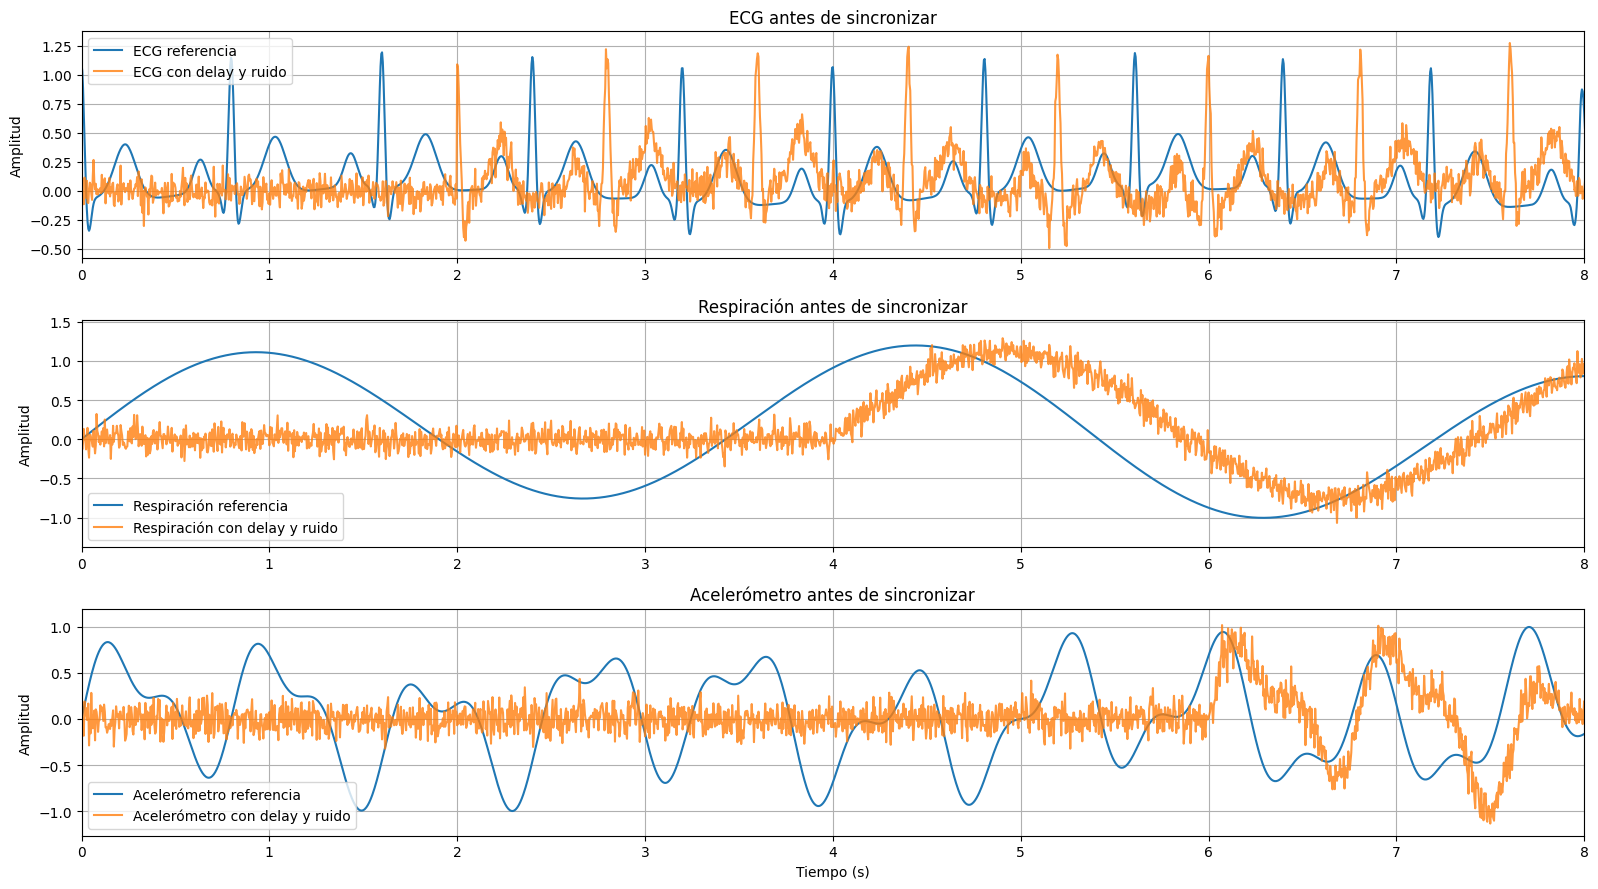

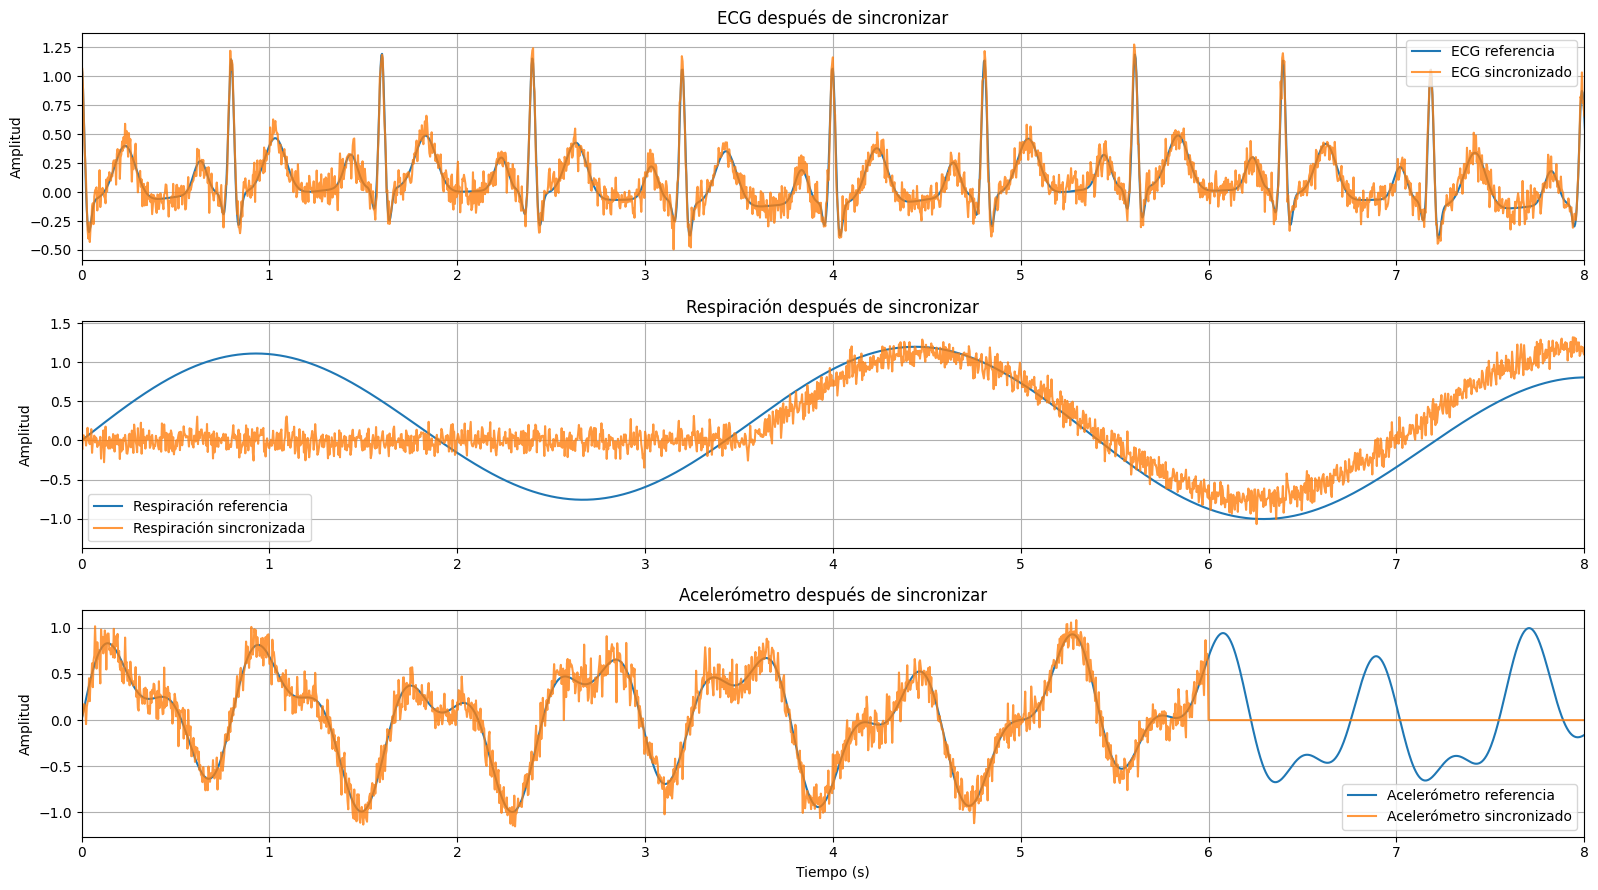

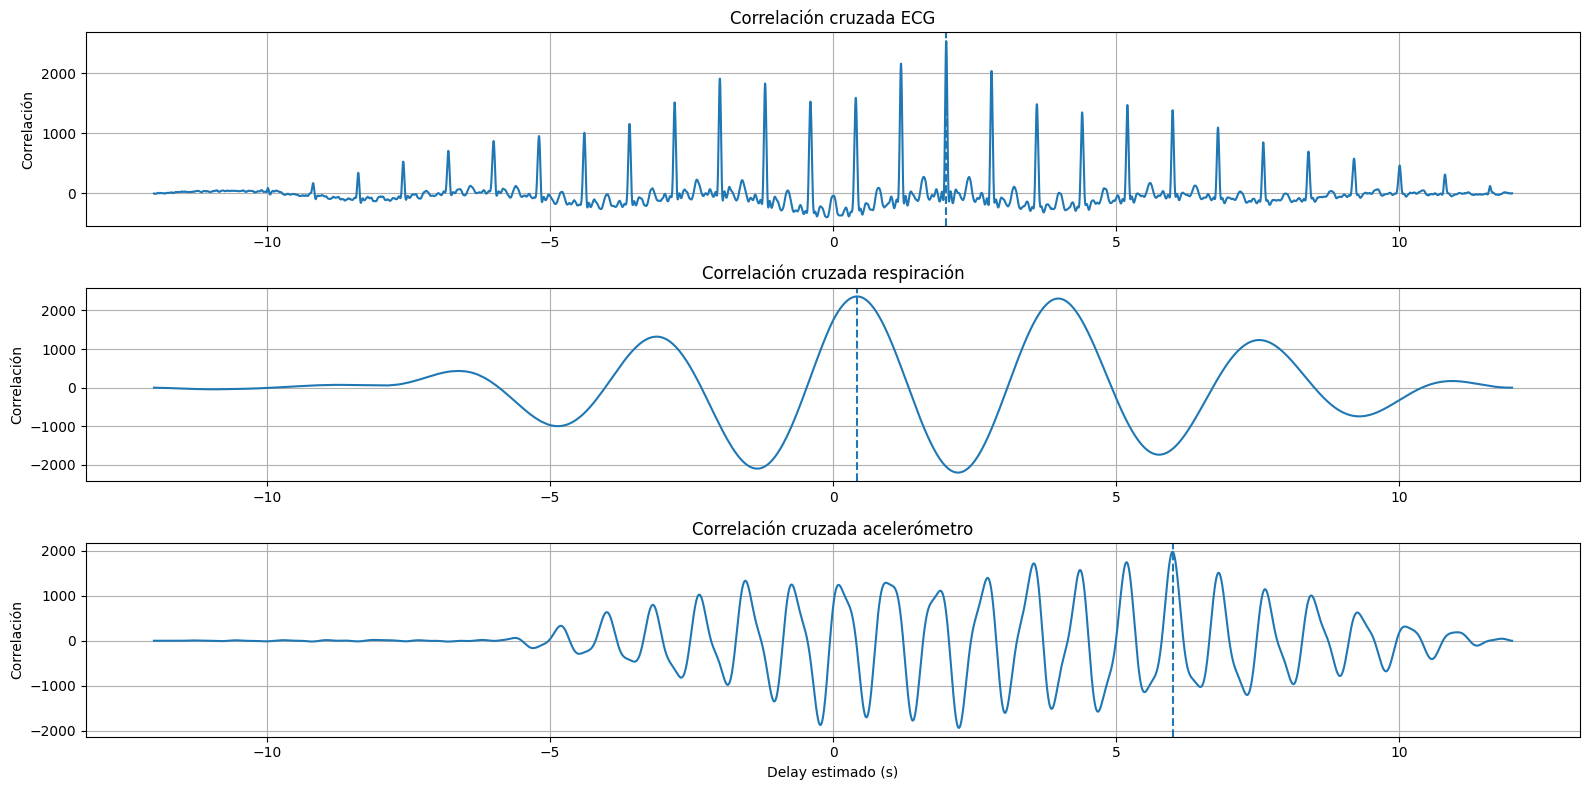

In [15]:
#EJERCICIO 5

from scipy.signal import correlate, correlation_lags

fs_sensores = 250
duracion_sensores = 12
t_sensores = np.arange(0, duracion_sensores, 1/fs_sensores)

#Delays distintos separados por 2 segundos
delay_ecg_s = 2
delay_resp_s = 4
delay_acc_s = 6

delay_ecg_muestras = delay_ecg_s * fs_sensores
delay_resp_muestras = delay_resp_s * fs_sensores
delay_acc_muestras = delay_acc_s * fs_sensores

# Señales limpias

#ECG sintético
ecg_referencia = nk.ecg_simulate(
    duration=duracion_sensores,
    sampling_rate=fs_sensores,
    heart_rate=75,
    noise=0
)

#Respiración simu
resp_referencia = 1.0 * np.sin(2 * np.pi * 0.28 * t_sensores)
resp_referencia += 0.25 * np.sin(2 * np.pi * 0.08 * t_sensores)

#Acelerómetro
acc_referencia = 0.6 * np.sin(2 * np.pi * 1.2 * t_sensores)
acc_referencia += 0.3 * np.sin(2 * np.pi * 2.5 * t_sensores)
acc_referencia += 0.2 * np.sin(2 * np.pi * 0.4 * t_sensores)


def aplicar_delay(senal, delay_muestras):
    """
    Desplaza una señal hacia la derecha.
    Se agregan ceros al inicio y se recorta el final.
    """
    senal_retrasada = np.concatenate([
        np.zeros(delay_muestras),
        senal[:-delay_muestras]
    ])
    return senal_retrasada


#Delay a cada sensor
ecg_delay = aplicar_delay(ecg_referencia, delay_ecg_muestras)
resp_delay = aplicar_delay(resp_referencia, delay_resp_muestras)
acc_delay = aplicar_delay(acc_referencia, delay_acc_muestras)

#RUIDO GAUSSIANO
np.random.seed(50)

ecg_ruidoso = ecg_delay + 0.08 * np.random.normal(0, 1, len(ecg_delay))
resp_ruidosa = resp_delay + 0.10 * np.random.normal(0, 1, len(resp_delay))
acc_ruidoso = acc_delay + 0.12 * np.random.normal(0, 1, len(acc_delay))

# CORRELACIÓN CRUZADA PARA ESTIMAR DELAY

def normalizar(senal):
    return (senal - np.mean(senal)) / np.std(senal)


def estimar_delay_por_correlacion(senal_referencia, senal_retrasada):
    """
    Estima el delay entre una señal de referencia y una señal retrasada.
    """
    ref_norm = normalizar(senal_referencia)
    retrasada_norm = normalizar(senal_retrasada)

    corr = correlate(retrasada_norm, ref_norm, mode='full')
    lags = correlation_lags(len(retrasada_norm), len(ref_norm), mode='full')

    delay_estimado = lags[np.argmax(corr)]
    return delay_estimado, corr, lags


#delays
delay_ecg_estimado, corr_ecg, lags_ecg = estimar_delay_por_correlacion(ecg_referencia, ecg_ruidoso)
delay_resp_estimado, corr_resp, lags_resp = estimar_delay_por_correlacion(resp_referencia, resp_ruidosa)
delay_acc_estimado, corr_acc, lags_acc = estimar_delay_por_correlacion(acc_referencia, acc_ruidoso)

print("Delay ECG estimado en muestras:", delay_ecg_estimado)
print("Delay ECG estimado en segundos:", delay_ecg_estimado / fs_sensores)

print("Delay respiración estimado en muestras:", delay_resp_estimado)
print("Delay respiración estimado en segundos:", delay_resp_estimado / fs_sensores)

print("Delay acelerómetro estimado en muestras:", delay_acc_estimado)
print("Delay acelerómetro estimado en segundos:", delay_acc_estimado / fs_sensores)

#SINCRONIZACIÓN

def sincronizar_senal(senal_retrasada, delay_estimado):
    """
    Corrige el retraso desplazando la señal hacia la izquierda.
    """
    if delay_estimado > 0:
        senal_sincronizada = np.concatenate([
            senal_retrasada[delay_estimado:],
            np.zeros(delay_estimado)
        ])
    elif delay_estimado < 0:
        delay_abs = abs(delay_estimado)
        senal_sincronizada = np.concatenate([
            np.zeros(delay_abs),
            senal_retrasada[:-delay_abs]
        ])
    else:
        senal_sincronizada = senal_retrasada.copy()

    return senal_sincronizada


ecg_sincronizado = sincronizar_senal(ecg_ruidoso, delay_ecg_estimado)
resp_sincronizada = sincronizar_senal(resp_ruidosa, delay_resp_estimado)
acc_sincronizado = sincronizar_senal(acc_ruidoso, delay_acc_estimado)

#ANTES DE LA SINCRONIZACIÓN

plt.figure(figsize=(16, 9))

plt.subplot(3, 1, 1)
plt.plot(t_sensores, ecg_referencia, label="ECG referencia")
plt.plot(t_sensores, ecg_ruidoso, label="ECG con delay y ruido", alpha=0.8)
plt.title("ECG antes de sincronizar")
plt.ylabel("Amplitud")
plt.xlim(0, 8)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_sensores, resp_referencia, label="Respiración referencia")
plt.plot(t_sensores, resp_ruidosa, label="Respiración con delay y ruido", alpha=0.8)
plt.title("Respiración antes de sincronizar")
plt.ylabel("Amplitud")
plt.xlim(0, 8)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_sensores, acc_referencia, label="Acelerómetro referencia")
plt.plot(t_sensores, acc_ruidoso, label="Acelerómetro con delay y ruido", alpha=0.8)
plt.title("Acelerómetro antes de sincronizar")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 8)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

#DESPUÉS DE LA SINCRONIZACIÓN

plt.figure(figsize=(16, 9))

plt.subplot(3, 1, 1)
plt.plot(t_sensores, ecg_referencia, label="ECG referencia")
plt.plot(t_sensores, ecg_sincronizado, label="ECG sincronizado", alpha=0.8)
plt.title("ECG después de sincronizar")
plt.ylabel("Amplitud")
plt.xlim(0, 8)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_sensores, resp_referencia, label="Respiración referencia")
plt.plot(t_sensores, resp_sincronizada, label="Respiración sincronizada", alpha=0.8)
plt.title("Respiración después de sincronizar")
plt.ylabel("Amplitud")
plt.xlim(0, 8)
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_sensores, acc_referencia, label="Acelerómetro referencia")
plt.plot(t_sensores, acc_sincronizado, label="Acelerómetro sincronizado", alpha=0.8)
plt.title("Acelerómetro después de sincronizar")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 8)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

#CORRELACIÓN CRUZADA

plt.figure(figsize=(16, 8))

plt.subplot(3, 1, 1)
plt.plot(lags_ecg / fs_sensores, corr_ecg)
plt.axvline(delay_ecg_estimado / fs_sensores, linestyle="--")
plt.title("Correlación cruzada ECG")
plt.ylabel("Correlación")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(lags_resp / fs_sensores, corr_resp)
plt.axvline(delay_resp_estimado / fs_sensores, linestyle="--")
plt.title("Correlación cruzada respiración")
plt.ylabel("Correlación")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(lags_acc / fs_sensores, corr_acc)
plt.axvline(delay_acc_estimado / fs_sensores, linestyle="--")
plt.title("Correlación cruzada acelerómetro")
plt.xlabel("Delay estimado (s)")
plt.ylabel("Correlación")
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
print("Se generó tres señales biomédicas: ECG, respiración y acelerómetro.")
print("A cada señal se le aplicó un delay distinto separado por 2 segundos y ruido gaussiano.")
print("La correlación cruzada permitió estimar el desplazamiento temporal entre la señal de referencia y la señal retrasada.")
print("Luego, cada señal fue desplazada en sentido contrario para sincronizarla.")
print("Después de la sincronización, las señales retrasadas se alinean mejor con sus respectivas señales de referencia.")

Se generó tres señales biomédicas: ECG, respiración y acelerómetro.
A cada señal se le aplicó un delay distinto separado por 2 segundos y ruido gaussiano.
La correlación cruzada permitió estimar el desplazamiento temporal entre la señal de referencia y la señal retrasada.
Luego, cada señal fue desplazada en sentido contrario para sincronizarla.
Después de la sincronización, las señales retrasadas se alinean mejor con sus respectivas señales de referencia.


In [17]:
#EJERCICIO 6
from scipy.signal import resample

fs_ecg6 = 500
fs_resp6 = 100
fs_acc6 = 200

duracion6 = 10

t_ecg6 = np.arange(0, duracion6, 1/fs_ecg6)
t_resp6 = np.arange(0, duracion6, 1/fs_resp6)
t_acc6 = np.arange(0, duracion6, 1/fs_acc6)

#ECG sintético
ecg_500hz = nk.ecg_simulate(
    duration=duracion6,
    sampling_rate=fs_ecg6,
    heart_rate=75,
    noise=0.01
)

#Respiración a 100 Hz
resp_100hz = 1.0 * np.sin(2 * np.pi * 0.25 * t_resp6)
resp_100hz += 0.15 * np.random.normal(0, 1, len(t_resp6))

#Acelerómetro a 200 Hz
acc_200hz = 0.6 * np.sin(2 * np.pi * 1.5 * t_acc6)
acc_200hz += 0.3 * np.sin(2 * np.pi * 3.0 * t_acc6)
acc_200hz += 0.12 * np.random.normal(0, 1, len(t_acc6))

Número de muestras ECG: 5000
Número de muestras respiración: 5000
Número de muestras acelerómetro: 5000
Frecuencia final común: 500 Hz
Todas las señales tienen la misma duración: 10 segundos


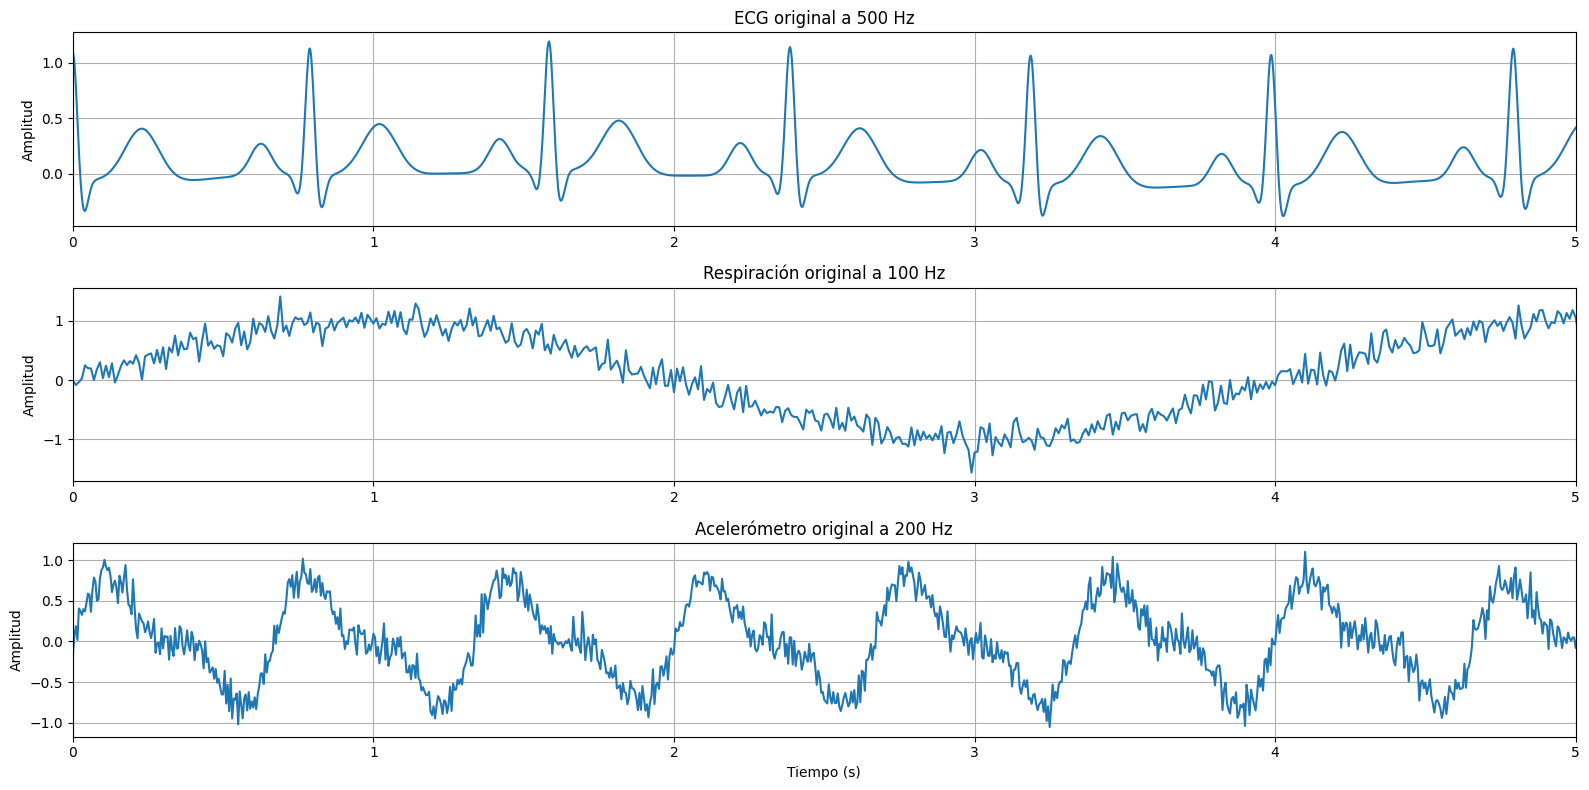

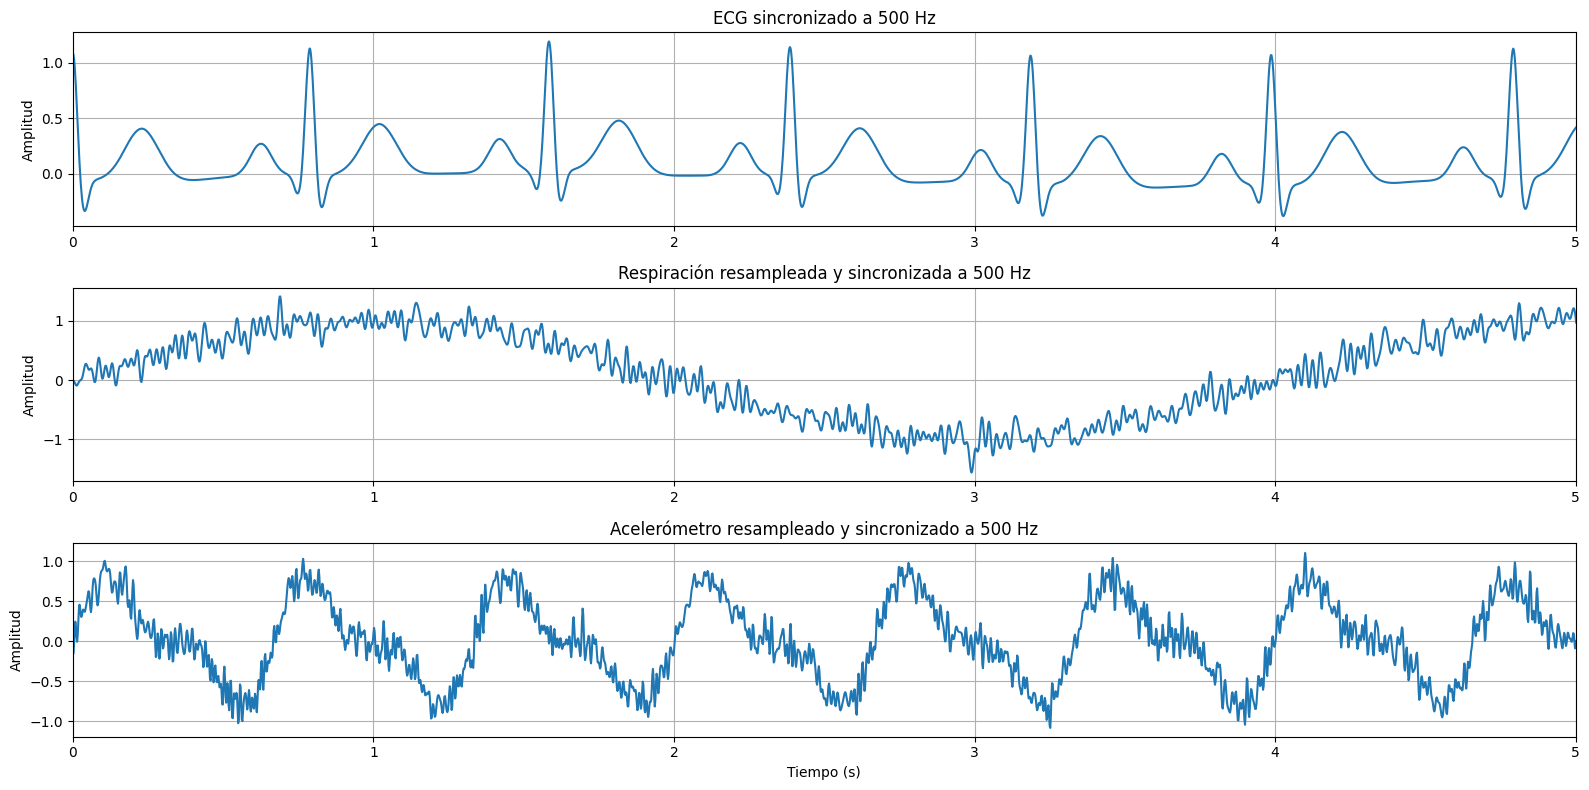

Tamaño de la matriz fusionada: (5000, 3)
Columnas: ECG, Respiración, Acelerómetro


In [18]:
#muestras objetivo igual al ECG
num_muestras_500hz = len(ecg_500hz)

#Respiración de 100 Hz a 500 Hz
resp_resampled_500hz = resample(resp_100hz, num_muestras_500hz)

#Acelerómetro de 200 Hz a 500 Hz
acc_resampled_500hz = resample(acc_200hz, num_muestras_500hz)

#ECG ya está a 500 Hz
ecg_resampled_500hz = ecg_500hz

#Nuevo vector de tiempo común a 500 Hz
t_comun_500hz = np.arange(0, duracion6, 1/fs_ecg6)

print("Número de muestras ECG:", len(ecg_resampled_500hz))
print("Número de muestras respiración:", len(resp_resampled_500hz))
print("Número de muestras acelerómetro:", len(acc_resampled_500hz))

print("Frecuencia final común:", fs_ecg6, "Hz")
print("Todas las señales tienen la misma duración:", duracion6, "segundos")


plt.figure(figsize=(16, 8))

plt.subplot(3, 1, 1)
plt.plot(t_ecg6, ecg_500hz)
plt.title("ECG original a 500 Hz")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t_resp6, resp_100hz)
plt.title("Respiración original a 100 Hz")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_acc6, acc_200hz)
plt.title("Acelerómetro original a 200 Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.tight_layout()
plt.show()

#RESAMPLEADAS A 500 Hz
plt.figure(figsize=(16, 8))

plt.subplot(3, 1, 1)
plt.plot(t_comun_500hz, ecg_resampled_500hz)
plt.title("ECG sincronizado a 500 Hz")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t_comun_500hz, resp_resampled_500hz)
plt.title("Respiración resampleada y sincronizada a 500 Hz")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_comun_500hz, acc_resampled_500hz)
plt.title("Acelerómetro resampleado y sincronizado a 500 Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 5)
plt.grid(True)

plt.tight_layout()
plt.show()

#=FUSIÓN MULTISENSOR
datos_fusionados = np.column_stack([
    ecg_resampled_500hz,
    resp_resampled_500hz,
    acc_resampled_500hz
])

print("Tamaño de la matriz fusionada:", datos_fusionados.shape)
print("Columnas: ECG, Respiración, Acelerómetro")

In [19]:
print("El ECG fue adquirido a 500 Hz, la respiración a 100 Hz y el acelerómetro a 200 Hz.")
print("Para poder fusionarlas, respiración y acelerómetro fueron remuestreados a 500 Hz.")
print("Después del resampling, todas las señales tienen el mismo número de muestras, la misma duración y el mismo vector temporal.")
print("Esto permite analizarlas de forma sincronizada en un sistema multisensor.")

El ECG fue adquirido a 500 Hz, la respiración a 100 Hz y el acelerómetro a 200 Hz.
Para poder fusionarlas, respiración y acelerómetro fueron remuestreados a 500 Hz.
Después del resampling, todas las señales tienen el mismo número de muestras, la misma duración y el mismo vector temporal.
Esto permite analizarlas de forma sincronizada en un sistema multisensor.
